In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models
print("GPU disponible :", tf.config.list_physical_devices('GPU'))

GPU disponible : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [5]:
# ── loading the data set ──────────────────────────────────
DATA_DIR = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"

df = pd.read_csv(f"{DATA_DIR}/Data_Entry_2017.csv")

print(f"✓ Dataset chargé : {len(df):,} lignes")
print(f"✓ Colonnes : {df.columns.tolist()}")
print(f"\n{df.head(3)}")

✓ Dataset chargé : 112,120 lignes
✓ Colonnes : ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']

        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   

   OriginalImagePixelSpacing[x     y]  Unnamed: 11  
0                        0.143  0.143          NaN  
1                        0.143  0.143          Na

In [6]:
# 14 pathologies officielles CheXNet
diseases = [
    'Atelectasis', 'Consolidation', 'Infiltration', 'Pneumothorax',
    'Edema', 'Emphysema', 'Fibrosis', 'Effusion', 'Pneumonia',
    'Pleural_Thickening', 'Cardiomegaly', 'Nodule', 'Mass', 'Hernia'
]

print(f"✓ {len(diseases)} pathologies à prédire")

✓ 14 pathologies à prédire


In [7]:
# Créer 14 colonnes binaires
for disease in diseases:
    df[disease] = df['Finding Labels'].apply(lambda x: 1 if disease in x.split('|') else 0)

print("✓ 14 colonnes binaires créées")
print("\nDistribution des maladies :")
print(df[diseases].sum().sort_values())

✓ 14 colonnes binaires créées

Distribution des maladies :
Hernia                  227
Pneumonia              1431
Fibrosis               1686
Edema                  2303
Emphysema              2516
Cardiomegaly           2776
Pleural_Thickening     3385
Consolidation          4667
Pneumothorax           5302
Mass                   5782
Nodule                 6331
Atelectasis           11559
Effusion              13317
Infiltration          19894
dtype: int64


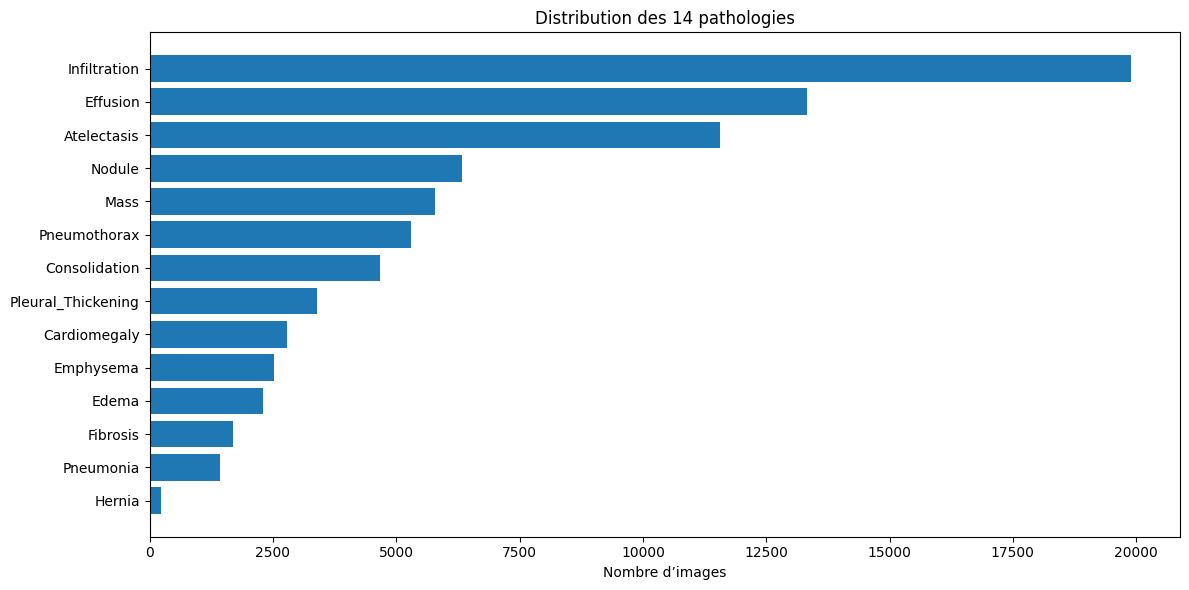

In [8]:
plt.figure(figsize=(12, 6))
counts = df[diseases].sum().sort_values()
plt.barh(counts.index, counts.values)
plt.xlabel('Nombre d’images')
plt.title('Distribution des 14 pathologies')
plt.tight_layout()
plt.show()

In [9]:
# Split patients : 80% train, 10% val, 10% test
unique_patients = df['Patient ID'].unique()

train_patients, temp_patients = train_test_split(
    unique_patients, test_size=0.2, random_state=42
)
val_patients, test_patients = train_test_split(
    temp_patients, test_size=0.5, random_state=42
)

# Créer les dataframes
train_df = df[df['Patient ID'].isin(train_patients)].copy()
val_df   = df[df['Patient ID'].isin(val_patients)].copy()
test_df  = df[df['Patient ID'].isin(test_patients)].copy()

print(f"Train images : {len(train_df):,}  | patients : {train_df['Patient ID'].nunique():,}")
print(f"Val images   : {len(val_df):,}    | patients : {val_df['Patient ID'].nunique():,}")
print(f"Test images  : {len(test_df):,}   | patients : {test_df['Patient ID'].nunique():,}")


Train images : 89,826  | patients : 24,644
Val images   : 10,930    | patients : 3,080
Test images  : 11,364   | patients : 3,081


In [10]:
image_paths = {}
for i in range(1, 13):
    folder = os.path.join(DATA_DIR, f"images_{i:03d}", "images")
    if os.path.exists(folder):
        for fname in os.listdir(folder):
            image_paths[fname] = os.path.join(folder, fname)

print(f"✓ {len(image_paths):,} images indexées")

✓ 112,120 images indexées


In [11]:
train_df['image_path'] = train_df['Image Index'].map(image_paths)
val_df['image_path']   = val_df['Image Index'].map(image_paths)
test_df['image_path']  = test_df['Image Index'].map(image_paths)

print(f"Train paths : {train_df['image_path'].notna().sum():,}")
print(f"Val paths   : {val_df['image_path'].notna().sum():,}")
print(f"Test paths  : {test_df['image_path'].notna().sum():,}")

Train paths : 89,826
Val paths   : 10,930
Test paths  : 11,364


In [12]:
def load_image(path, labels):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(image, tf.float32) / 255.0
    return image, labels

In [13]:
# Datasets avec les 14 labels
train_dataset = tf.data.Dataset.from_tensor_slices((train_df['image_path'], train_df[diseases].values))
val_dataset   = tf.data.Dataset.from_tensor_slices((val_df['image_path'],   val_df[diseases].values))
test_dataset  = tf.data.Dataset.from_tensor_slices((test_df['image_path'],  test_df[diseases].values))

# Map + batch + prefetch
train_dataset = train_dataset.map(load_image).shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
val_dataset   = val_dataset.map(load_image).batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset  = test_dataset.map(load_image).batch(32).prefetch(tf.data.AUTOTUNE)

print("✓ Datasets prêts")

✓ Datasets prêts


I0000 00:00:1774962306.625259      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774962306.631442      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [14]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

def augment_image(image, labels):
    return augmentation(image), labels

train_dataset = train_dataset.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
print("✓ Augmentation appliquée au train")

✓ Augmentation appliquée au train


In [15]:
class_weights = {}
for i, disease in enumerate(diseases):
    y = train_df[disease].values
    weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
    class_weights[i] = weights[1]  # poids pour la classe 1

print("Class weights :")
for disease, weight in zip(diseases, class_weights.values()):
    print(f"  {disease:20} : {weight:.2f}")

Class weights :
  Atelectasis          : 4.80
  Consolidation        : 12.09
  Infiltration         : 2.84
  Pneumothorax         : 10.49
  Edema                : 24.29
  Emphysema            : 22.63
  Fibrosis             : 33.97
  Effusion             : 4.17
  Pneumonia            : 39.50
  Pleural_Thickening   : 16.48
  Cardiomegaly         : 20.81
  Nodule               : 8.89
  Mass                 : 9.54
  Hernia               : 250.91


In [16]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze les premières couches, fine-tune les dernières
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(14, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auroc'), 'accuracy']
)

print(f"✓ Modèle CheXNet créé")
print(f"Paramètres entraînables : {sum([p.numpy().size for p in model.trainable_variables]):,}")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ Modèle CheXNet créé
Paramètres entraînables : 6,163,534


In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        '/kaggle/working/chexnet_best.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

# Entraînement
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
    class_weight=class_weights   # add more penalty if the model do an errore in rare classe in our case Herina
)

Epoch 1/10


I0000 00:00:1774962384.131065     130 service.cc:152] XLA service 0x7d8d183314d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774962384.131105     130 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774962384.131110     130 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774962394.131747     130 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774962473.584575     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2808/2808 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.0980 - auroc: 0.6646 - loss: 1.8448
Epoch 1: val_loss improved from inf to 0.16545, saving model to /kaggle/working/chexnet_best.keras
2808/2808 ━━━━━━━━━━━━━━━━━━━━ 1351s 431ms/step - accuracy: 0.0980 - auroc: 0.6646 - loss: 1.8447 - val_accuracy: 0.1503 - val_auroc: 0.8198 - val_loss: 0.1655 - learning_rate: 1.0000e-04
Epoch 2/10
2807/2808 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.1513 - auroc: 0.7940 - loss: 1.3160
Epoch 2: val_loss improved from 0.16545 to 0.16192, saving model to /kaggle/working/chexnet_best.keras
2808/2808 ━━━━━━━━━━━━━━━━━━━━ 1089s 385ms/step - accuracy: 0.1513 - auroc: 0.7940 - loss: 1.3160 - val_accuracy: 0.1575 - val_auroc: 0.8357 - val_loss: 0.1619 - learning_rate: 1.0000e-04
Epoch 3/10
2807/2808 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.1641 - auroc: 0.8113 - loss: 1.2605
Epoch 3: val_loss did not improve from 0.16192
2808/2808 ━━━━━━━━━━━━━━━━━━━━ 1035s 366ms/step - accuracy: 0.1641 -

In [20]:
# evaluate the model on the test set
from tensorflow.keras.models import load_model
best_model = load_model('/kaggle/working/chexnet_best.keras')
# evaluate my model
test_loss, test_auroc, test_acc = best_model.evaluate(test_dataset)
print(f"Test Loss  : {test_loss:.4f}")
print(f"Test AUROC : {test_auroc:.4f}")


356/356 ━━━━━━━━━━━━━━━━━━━━ 85s 199ms/step - accuracy: 0.1430 - auroc: 0.8295 - loss: 0.1624
Test Loss  : 0.1665
Test AUROC : 0.8436


In [21]:
import numpy as np
from sklearn.metrics import roc_auc_score

# Récupérer toutes les vraies valeurs et prédictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = best_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(f"Shape y_true : {y_true.shape}")
print(f"Shape y_pred : {y_pred.shape}")

Shape y_true : (11364, 14)
Shape y_pred : (11364, 14)


In [53]:
# calculate AUROC per disease
AUROC_Per_Dis = {}
for i, disease in enumerate(diseases):
    true_label = y_true[:, i]
    predicted_label = y_pred[:, i]
    AUROC_Per_Dis[disease] = roc_auc_score(true_label, predicted_label)

# print every Auc of evry disases
for diseas , score in  AUROC_Per_Dis.items():
    print(f"{diseas} : {score:.4f}")

Atelectasis : 0.7622
Consolidation : 0.8017
Infiltration : 0.6811
Pneumothorax : 0.8519
Edema : 0.8934
Emphysema : 0.8979
Fibrosis : 0.7787
Effusion : 0.8629
Pneumonia : 0.7031
Pleural_Thickening : 0.7668
Cardiomegaly : 0.8641
Nodule : 0.7163
Mass : 0.8069
Hernia : 0.9211


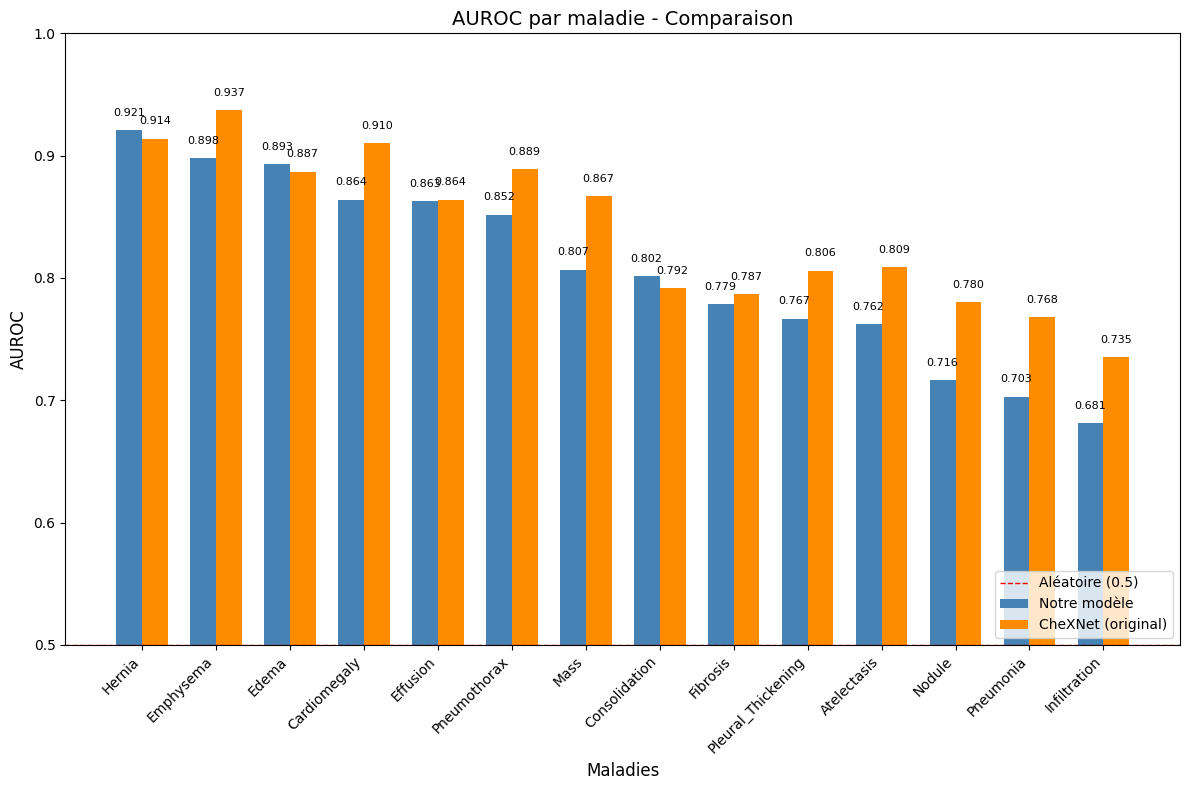

In [52]:
# Trier tes résultats
# this is case is work validation
my_result = dict(sorted(AUROC_Per_Dis.items(), key=lambda x: x[1], reverse=True))

# CheXNet original
chexnet_auroc = {
    'Atelectasis': 0.809,
    'Consolidation': 0.792,
    'Infiltration': 0.735,
    'Pneumothorax': 0.889,
    'Edema': 0.887,
    'Emphysema': 0.937,
    'Fibrosis': 0.787,
    'Effusion': 0.864,
    'Pneumonia': 0.768,
    'Pleural_Thickening': 0.806,
    'Cardiomegaly': 0.910,
    'Nodule': 0.780,
    'Mass': 0.867,
    'Hernia': 0.914
}

# Créer les listes dans le MÊME ORDRE (ordre de my_result)
my_list = []
my_values = []
chexnet_values = []

for disease in my_result.keys():
    my_list.append(disease)
    my_values.append(my_result[disease])
    chexnet_values.append(chexnet_auroc[disease])


import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import numpy as np

# Positions des barres
x = np.arange(len(my_list))  # [0, 1, 2, ..., 13]
width = 0.35  # largeur des barres

# Créer la figure
plt.figure(figsize=(12, 8))

# Tracer les barres
bars1 = plt.bar(x - width/2, my_values, width, label='Notre modèle', color='steelblue')
bars2 = plt.bar(x + width/2, chexnet_values, width, label='CheXNet (original)', color='darkorange')

# Ajouter les valeurs sur les barres (optionnel)
for bar, val in zip(bars1, my_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)

for bar, val in zip(bars2, chexnet_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# Ligne aléatoire
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Aléatoire (0.5)')

# Personnalisation
plt.xlabel('Maladies', fontsize=12)
plt.ylabel('AUROC', fontsize=12)
plt.title('AUROC par maladie - Comparaison', fontsize=14)
plt.xticks(x, my_list, rotation=45, ha='right')
plt.ylim(0.5, 1.0)
plt.legend(loc='lower right')

# Ajuster et afficher
plt.tight_layout()
plt.show()